# **Exploratory Data Analysis**

### Data quality check

In [28]:
import pandas as pd
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt

In [3]:
load_dotenv()  # Load environment variables from .env file
PROCESSED_DATA_PATH = os.getenv("DATA_ANALYSIS_PATH")  # Get the path to the processed data file from environment variables

In [4]:
df = pd.read_parquet(PROCESSED_DATA_PATH, engine='pyarrow')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ano           11 non-null     int64  
 1   Homens_Qtd    11 non-null     int64  
 2   Homens_Pct    11 non-null     float64
 3   Mulheres_Qtd  11 non-null     int64  
 4   Mulheres_Pct  11 non-null     float64
 5   Total_PF      11 non-null     int64  
dtypes: float64(2), int64(4)
memory usage: 660.0 bytes


In [8]:
df.head()

,Ano,Homens_Qtd,Homens_Pct,Mulheres_Qtd,Mulheres_Pct,Total_PF
0,2026,4822375,73.36,1751481,26.64,6573856
1,2025,4622233,74.13,1612682,25.87,6234915
2,2024,4479420,74.27,1552001,25.73,6031421
3,2023,4311129,75.17,1424322,24.83,5735451
4,2022,4505153,77.05,1342010,22.95,5847163


In [ ]:
#Total null values in each column
df.isna().sum()

Ano             0
Homens_Qtd      0
Homens_Pct      0
Mulheres_Qtd    0
Mulheres_Pct    0
Total_PF        0
dtype: int64

In [ ]:
#Data types of each column
df.dtypes

Ano               int64
Homens_Qtd        int64
Homens_Pct      float64
Mulheres_Qtd      int64
Mulheres_Pct    float64
Total_PF          int64
dtype: object

In [ ]:
#Total of duplicated rows
df.duplicated().sum()

np.int64(0)

In [19]:
#Minimum, maximum and total of years in the dataset
f"Start year: {df['Ano'].min()}"

'Start year: 2016'

In [20]:
f"End year: {df['Ano'].max()}"

'End year: 2026'

In [21]:
f"Total of years: {df['Ano'].nunique()}"

'Total of years: 11'

In [24]:
#Validating percentage columns
df["Gender_Pct_Total"] = df["Homens_Pct"] + df["Mulheres_Pct"]
df['Gender_Pct_Total']

0     100.0
1     100.0
2     100.0
3     100.0
4     100.0
5     100.0
6     100.0
7     100.0
8     100.0
9     100.0
10    100.0
Name: Gender_Pct_Total, dtype: float64

### KPIs

In [26]:
#Total of investors by year
df.groupby('Ano')['Total_PF'].sum()

Ano
2016     564529
2017     620313
2018     813974
2019    1666328
2020    3233727
2021    4976153
2022    5847163
2023    5735451
2024    6031421
2025    6234915
2026    6573856
Name: Total_PF, dtype: int64

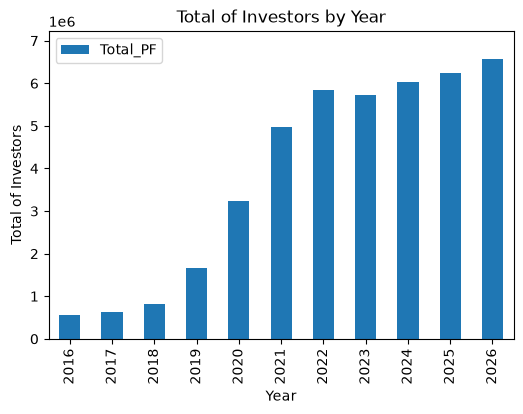

In [42]:
df = df.sort_values(by='Ano')

ax = df.plot(
    x='Ano',
    y='Total_PF',
    kind='bar',
    figsize=(6, 4),
    title='Total of Investors by Year'
)

ax.set_ylim(0, df['Total_PF'].max() * 1.1)
ax.set_xlabel('Year')
ax.set_ylabel('Total of Investors')

plt.show()

In [46]:
#YoY growth
df['YoY_Growth'] = df['Total_PF'].pct_change().round(3) * 100
df

,Ano,Homens_Qtd,Homens_Pct,Mulheres_Qtd,Mulheres_Pct,Total_PF,Gender_Pct_Total,YoY_Growth
10,2016,434142,76.90,130387,23.10,564529,100.0,NaN
9,2017,478408,77.12,141905,22.88,620313,100.0,9.9
8,2018,634413,77.94,179561,22.06,813974,100.0,31.2
7,2019,1277604,76.67,388724,23.33,1666328,100.0,104.7
6,2020,2385136,73.76,848591,26.24,3233727,100.0,94.1
5,2021,3822139,76.81,1154014,23.19,4976153,100.0,53.9
4,2022,4505153,77.05,1342010,22.95,5847163,100.0,17.5
3,2023,4311129,75.17,1424322,24.83,5735451,100.0,-1.9
2,2024,4479420,74.27,1552001,25.73,6031421,100.0,5.2
1,2025,4622233,74.13,1612682,25.87,6234915,100.0,3.4


In [ ]:
#Compound Annual Growth Rate (CAGR)
start_year = df['Ano'].min()
end_year = df['Ano'].max()

start_value = df.loc[df['Ano'] == start_year, 'Total_PF'].iloc[0]
end_value = df.loc[df['Ano'] == end_year, 'Total_PF'].iloc[0]

years = end_year - start_year

cagr = ((end_value / start_value) ** (1 / years) - 1) * 100

f"A {cagr:.2f}% annual growth rate would be required to reach the total number of investors in {end_year} from {start_year}."

'A 27.82% annual growth rate would be required to reach the total number of investors in 2026 from 2016.'

In [85]:
#Share of investors by gender in 2026
female_share = df.loc[df['Ano'] == end_year, 'Mulheres_Pct'].iloc[0]
male_share = df.loc[df['Ano'] == end_year, 'Homens_Pct'].iloc[0]

total_female = df.loc[df["Ano"] == end_year, "Mulheres_Qtd"].iloc[0]
total_male = df.loc[df["Ano"] == end_year, "Homens_Qtd"].iloc[0]

diff_of_investors = total_male - total_female

f"In {end_year}, {female_share:.2f}% of investors were female, compared with {male_share:.2f}% who were male. This represents a difference of {diff_of_investors:,} investors."

'In 2026, 26.64% of investors were female, compared with 73.36% who were male. This represents a difference of 3,070,894 investors.'

In [87]:
#Female Share Change
df["Female_Share_Change"] = df["Mulheres_Pct"].diff()
df

,Ano,Homens_Qtd,Homens_Pct,Mulheres_Qtd,Mulheres_Pct,Total_PF,Gender_Pct_Total,YoY_Growth,Female_Share_Change
10,2016,434142,76.90,130387,23.10,564529,100.0,NaN,NaN
9,2017,478408,77.12,141905,22.88,620313,100.0,9.9,-0.22
8,2018,634413,77.94,179561,22.06,813974,100.0,31.2,-0.82
7,2019,1277604,76.67,388724,23.33,1666328,100.0,104.7,1.27
6,2020,2385136,73.76,848591,26.24,3233727,100.0,94.1,2.91
5,2021,3822139,76.81,1154014,23.19,4976153,100.0,53.9,-3.05
4,2022,4505153,77.05,1342010,22.95,5847163,100.0,17.5,-0.24
3,2023,4311129,75.17,1424322,24.83,5735451,100.0,-1.9,1.88
2,2024,4479420,74.27,1552001,25.73,6031421,100.0,5.2,0.90
1,2025,4622233,74.13,1612682,25.87,6234915,100.0,3.4,0.14
